# Find Best Model


In [2]:
from typing import Callable
from types import SimpleNamespace
from collections import defaultdict
import os
import glob
import math
import numpy as np
import pandas as pd
import torch
import lightning as pl
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import matplotlib.pyplot as plt
from matplotlib.pyplot import subplots


from tqdm import tqdm

from meta import load_meta
from model import MultiLayerLeakyReLUModel
from nearest_neighbour_model import (
    NearestNeighbourModel,
    NearestNeighboursInterpolationModel,
)

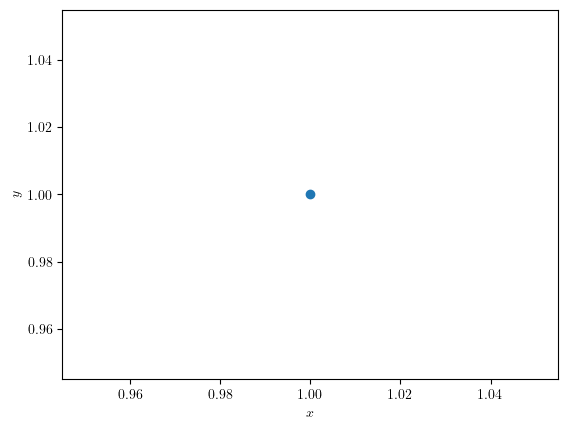

In [3]:
# use latex in matplotlib
plt.rcParams["text.usetex"] = True

# test
plt.scatter([1], [1])

plt.xlabel("$x$")
plt.ylabel("$y$")
plt.show()

In [4]:
import warnings

# ignore frequent warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

## Args


### Demo


In [5]:
# args = SimpleNamespace(
#     # io
#     logs_path="data/logs",
#     experiment_name="demo_experiment",
# )


# latex_symbol = {}
# latex_unit = {}
# scaling_factor = {}
# scale_type = {}

### laser-pulse-shaping-astra-sim


In [6]:
# args = SimpleNamespace(
#     # io
#     data_path="data/laser-pulse-shaping-astra-sim-v11-ln-emit-normalized",
#     logs_path="data/logs",
#     experiment_name="laser-pulse-shaping-astra-sim-v11-ln-emit-normalized",  # use .old for previous version
# )

args = SimpleNamespace(
    # io
    data_path="data/laser-pulse-shaping-astra-sim-v20-no-twiss-ln-std-emit-normalized-outliers-removed",
    logs_path="data/logs",
    experiment_name="laser-pulse-shaping-astra-sim-v20-no-twiss-ln-std-emit-normalized-outliers-removed",
)


latex_symbol = {
    "std_x-final": r"\sigma_{x}",
    "std_px-final": r"\sigma_{p_{x}}",
    "norm_emit_x-final": r"\varepsilon^{norm}_{xy}",
    "std_z-final": r"\sigma_{z}",
    "mean_kinetic_energy-final": r"\bar{E}",
    "std_kinetic_energy-final": r"\sigma_{E}",
    **{f"latent vector component {i:02d}": rf"s_{{{i:02d}}}" for i in range(32)},
    "gun_phase": r"\varphi",
    "gun_B_max": r"B_{z,0}",
}
latex_unit = {
    "std_x-final": r"mm",
    "std_px-final": r"keV/c",
    "norm_emit_x-final": r"mm~mrad",
    "std_z-final": r"mm",
    "mean_kinetic_energy-final": r"MeV",
    "std_kinetic_energy-final": r"keV",
    **{f"latent vector component {i:02d}": None for i in range(32)},
    "gun_phase": r"deg",
    "gun_B_max": r"T",
}
scaling_factor = {
    "std_x-final": 1e3,
    "std_px-final": 1e-3,
    "norm_emit_x-final": 1e6,
    "std_z-final": 1e3,
    "mean_kinetic_energy-final": 1e-6,
    "std_kinetic_energy-final": 1e-3,
}
scale_type = {
    "std_x-final": "log",
    "norm_emit_x-final": "log",
    "std_px-final": "log",
}


def axis_label(param: str) -> str:
    s = ""
    if param in latex_symbol:
        s += "$" + latex_symbol[param] + "$"
    else:
        s += param
    if param in latex_unit and latex_unit[param] is not None:
        s += " [" + latex_unit.get(param, "a.u.") + "]"
    return s


axis_label("std_x-final"), axis_label("gun_phase"), axis_label("unknown_param")

('$\\sigma_{x}$ [mm]', '$\\varphi$ [deg]', 'unknown_param')

### load data


In [7]:
best_version_path = os.path.join(args.logs_path, args.experiment_name, "_best")
best_ckpt_path = os.path.join(best_version_path, "best.ckpt")

In [8]:
def _partial_apply(
    x: torch.Tensor,
    func: Callable[[torch.Tensor], torch.Tensor],
    slc: list[slice | list[int]],
) -> torch.Tensor:
    y = x.clone()
    y[*slc] = func(x[*slc])
    return y

In [9]:
data = np.load(os.path.join(args.data_path, "test.npz"))
data_train = np.load(os.path.join(args.data_path, "train.npz"))

data_meta = load_meta(args.data_path)
x_size = data_meta["input_size"]
y_size = data_meta["output_size"]
x_params = data_meta["columns"][:x_size]
y_params = data_meta["columns"][x_size:]
x_std = (
    torch.tensor(data_meta["normalization_original_std"][:x_size])
    if "normalization_original_std" in data_meta
    else torch.ones(x_size)
)
x_mean = (
    torch.tensor(data_meta["normalization_original_mean"][:x_size])
    if "normalization_original_mean" in data_meta
    else torch.zeros(x_size)
)
y_std = (
    torch.tensor(data_meta["normalization_original_std"][x_size:])
    if "normalization_original_std" in data_meta
    else torch.ones(y_size)
)
y_mean = (
    torch.tensor(data_meta["normalization_original_mean"][x_size:])
    if "normalization_original_mean" in data_meta
    else torch.zeros(y_size)
)
_slice_y_emit = [i for i, y in enumerate(y_params) if "emit" in y]
_slice_y_std_emit = [i for i, y in enumerate(y_params) if "std" in y or "emit" in y]
x_inner_trafo = lambda x: x
y_inner_trafo = (
    (lambda y: _partial_apply(y, np.log, [slice(None), _slice_y_emit]))
    if "ln-emit" in args.data_path
    else (
        (lambda y: _partial_apply(y, np.log, [slice(None), _slice_y_std_emit]))
        if "ln-std-emit" in args.data_path
        else lambda y: y
    )
)
x_outer_back_trafo = lambda x: x
y_outer_back_trafo = (
    (lambda y: _partial_apply(y, np.exp, [slice(None), _slice_y_emit]))
    if "ln-emit" in args.data_path
    else (
        (lambda y: _partial_apply(y, np.exp, [slice(None), _slice_y_std_emit]))
        if "ln-std-emit" in args.data_path
        else lambda y: y
    )
)

assert len(x_params) == x_size
assert len(y_params) == y_size
from types import SimpleNamespace

pd.Series(data_meta)

author                                                                  kwasniok
date                                            2026-02-07T16:39:22.000070+00:00
description                    Dataset for surrogate modeling of ASTRA simula...
data_path                      data/laser-pulse-shaping-astra-sim-v20-no-twis...
input_size                                                                    36
output_size                                                                    6
columns                        [latent vector component 00, latent vector com...
normalization_original_mean    [-0.1602218962229531, -0.13372278541069285, -0...
normalization_original_std     [0.9779308242588357, 0.8644431027148368, 0.863...
dtype: object

### load model


In [10]:
model = MultiLayerLeakyReLUModel.load_from_checkpoint(best_ckpt_path)
model.eval()
model.requires_grad_(False)

MultiLayerLeakyReLUModel(
  (loss_fn): MSELoss()
  (sequence): Sequential(
    (0): Linear(in_features=36, out_features=40, bias=True)
    (1): LeakyReLU(negative_slope=0.1)
    (2): Linear(in_features=40, out_features=40, bias=True)
    (3): LeakyReLU(negative_slope=0.1)
    (4): Linear(in_features=40, out_features=40, bias=True)
    (5): LeakyReLU(negative_slope=0.1)
    (6): Linear(in_features=40, out_features=40, bias=True)
    (7): LeakyReLU(negative_slope=0.1)
    (8): Linear(in_features=40, out_features=40, bias=True)
    (9): LeakyReLU(negative_slope=0.1)
    (10): Linear(in_features=40, out_features=6, bias=True)
  )
)

### evaluate model


In [11]:
epsilon = 1e-12

In [12]:
def trafo_x(x):
    return (x_inner_trafo(x) - x_mean) / x_std


def trafo_y(y):
    return (y_inner_trafo(y) - y_mean) / y_std


def back_trafo_x(x):
    return x_outer_back_trafo(x * x_std + x_mean)


def back_trafo_y(y):
    return y_outer_back_trafo(y * y_std + y_mean)

In [13]:
def make_results(model: pl.LightningModule, data: dict) -> pd.DataFrame:

    results = defaultdict(list)
    with torch.no_grad():

        x = torch.tensor(data["x"], dtype=torch.float32)
        y = torch.tensor(data["y"], dtype=torch.float32)
        meta = {k: v for k, v in data.items() if k not in ["x", "y"]}

        y_pred = model(x)

        # transform back
        x = back_trafo_x(x)
        y = back_trafo_y(y)
        y_pred = back_trafo_y(y_pred)

        results["x"] = x
        results["y"] = y
        results["y_pred"] = y_pred
        results["y_rel_err"] = (y_pred - y) / (y)
        results["y_abs_rel_err"] = ((y_pred - y) / (y)).abs()

    for k, v in results.items():
        results[k] = v.cpu().numpy()

    results = (
        {k: results["x"][:, i] for i, k in enumerate(x_params)}
        | {k: results["y"][:, i] for i, k in enumerate(y_params)}
        | {f"{k} prediciton": results["y_pred"][:, i] for i, k in enumerate(y_params)}
        | {
            f"{k} rel. error": results["y_rel_err"][:, i]
            for i, k in enumerate(y_params)
        }
        | {
            f"{k} abs. rel. error": results["y_abs_rel_err"][:, i]
            for i, k in enumerate(y_params)
        }
    )

    results |= meta

    results = pd.DataFrame(results)

    return results


results = make_results(model, data)

for c in results.select_dtypes(include=["number"]).columns:
    if not c.startswith("log_10)"):
        results[f"log_10({c})"] = np.log10(results[c])

/home/kwasniok/.venv/ml/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/kwasniok/.venv/ml/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/kwasniok/.venv/ml/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/kwasniok/.venv/ml/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/kwasniok/.venv/ml/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/kwasniok/.venv/ml/lib/python3.11/site-packages/pandas/core/

In [14]:
results.describe().transpose()

/home/kwasniok/.venv/ml/lib/python3.11/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
/home/kwasniok/.venv/ml/lib/python3.11/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
/home/kwasniok/.venv/ml/lib/python3.11/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
/home/kwasniok/.venv/ml/lib/python3.11/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,count,mean,std,min,25%,50%,75%,max
latent vector component 00,3165.0,-0.195555,0.976286,-4.080509,-0.800916,-0.162667,0.383503,3.357841
latent vector component 01,3165.0,-0.144183,0.855147,-2.701918,-0.698841,-0.148926,0.462261,2.938548
latent vector component 02,3165.0,-0.467907,0.829213,-3.973869,-0.958554,-0.406084,0.059010,2.701413
latent vector component 03,3165.0,-0.169227,0.905241,-3.021171,-0.805925,-0.295230,0.346265,3.577345
latent vector component 04,3165.0,-0.051378,0.829052,-3.360749,-0.559062,-0.054487,0.468108,3.442501
...,...,...,...,...,...,...,...,...
log_10(std_px-final abs. rel. error),3165.0,-1.813199,0.570656,-4.844294,-2.105457,-1.757674,-1.437401,-0.145528
log_10(norm_emit_x-final abs. rel. error),3165.0,-1.573433,0.511548,-4.939813,-1.838058,-1.499817,-1.226154,-0.298660
log_10(std_z-final abs. rel. error),3165.0,-inf,NaN,-inf,-2.572473,-2.233108,-1.954208,-1.022744
log_10(mean_kinetic_energy-final abs. rel. error),3165.0,-inf,NaN,-inf,-4.972480,-4.631525,-4.385355,-3.054733


In [15]:
# def show_results_overview(
#     tag: str,
#     results: pd.DataFrame,
# ):
#     def f(cluster, df):
#         corr = df.select_dtypes(include="number").corr()
#         px.imshow(
#             corr,
#             color_continuous_scale="RdBu",
#             zmin=-1,
#             zmax=1,
#             title=cluster,
#         ).show()

#         cols = [col for col in df.columns if col.endswith("abs. rel. error")]
#         fig = px.histogram(
#             df,
#             x=cols,
#             title=f"histogram for cluster {cluster}",
#             barmode="overlay",
#         )
#         fig.show()

#     for k, v in results.groupby("laser_pulse_shape_cluster_id"):
#         f(k, v)


# show_results_overview("", results)

In [16]:
def make_abs_rel_error_threshold_table(
    tag: str,
    results: pd.DataFrame,
    abs_rel_err_threshold: float = 0.10,
):
    frac = abs_rel_err_threshold
    table = pd.DataFrame()

    def f(cluster, df):
        cols = [col for col in df.columns if col.endswith("abs. rel. error")]
        row = (df[cols] < frac).mean() * 100
        return row.to_frame(name=cluster).T

    for k, v in results.groupby("laser_pulse_shape_cluster_id"):
        df = f(k, v)
        table = pd.concat([table, df])

    df = f("all", results)

    table = pd.concat([table, df])
    table["threshold (%)"] = frac * 100

    return table


make_abs_rel_error_threshold_table("", results).round(1)

,std_x-final abs. rel. error,std_px-final abs. rel. error,norm_emit_x-final abs. rel. error,std_z-final abs. rel. error,mean_kinetic_energy-final abs. rel. error,std_kinetic_energy-final abs. rel. error,threshold (%)
C1,96.1,95.5,94.7,100.0,100.0,99.9,10.0
C2,96.1,94.9,87.4,100.0,100.0,99.2,10.0
C3,95.8,95.3,85.6,100.0,100.0,99.2,10.0
C4,94.8,93.3,87.0,100.0,100.0,99.4,10.0
C5,96.3,95.2,93.8,100.0,100.0,99.5,10.0
C6,97.1,94.7,91.5,100.0,100.0,99.6,10.0
all,96.1,94.8,90.4,100.0,100.0,99.5,10.0


In [17]:
def make_abs_rel_error_mean_table(
    tag: str,
    results: pd.DataFrame,
):
    table = pd.DataFrame()

    def f(cluster, df):
        cols = [col for col in df.columns if col.endswith("abs. rel. error")]
        row = df[cols].mean() * 100
        return row.to_frame(name=cluster).T

    for k, v in results.groupby("laser_pulse_shape_cluster_id"):
        df = f(k, v)
        table = pd.concat([table, df])

    df = f("all", results)

    table = pd.concat([table, df])

    return table


make_abs_rel_error_mean_table("", results)  # .round(1)

,std_x-final abs. rel. error,std_px-final abs. rel. error,norm_emit_x-final abs. rel. error,std_z-final abs. rel. error,mean_kinetic_energy-final abs. rel. error,std_kinetic_energy-final abs. rel. error
C1,2.459643,2.796988,3.559719,0.711822,0.002692,1.421128
C2,2.749873,3.140316,4.923645,0.888775,0.003741,1.992640
C3,2.721005,3.286356,5.338821,1.027498,0.003908,2.012139
C4,2.865922,3.126559,5.513052,0.914530,0.003723,1.918291
C5,2.587522,2.827272,3.756142,0.779314,0.002812,1.503722
C6,2.537585,3.065888,4.168559,0.880364,0.003331,1.767135
all,2.646081,3.013602,4.463147,0.845197,0.003315,1.746275


In [18]:
def change_rgba_opacity(rgba: str, new_opacity: float) -> str:
    """Changes the opacity of an RGBA color string."""
    parts = rgba.strip("rgba()").split(",")
    if len(parts) != 4:
        raise ValueError("Input must be an RGBA color string.")
    parts[3] = str(new_opacity)
    return "rgba(" + ",".join(parts) + ")"


def add_rgb_opacity(rgb: str, opacity: float) -> str:
    """Adds opacity to an RGB color string, converting it to RGBA."""
    parts = rgb.strip("rgb()").split(",")
    if len(parts) != 3:
        raise ValueError("Input must be an RGB color string.")
    parts.append(str(opacity))
    return "rgba(" + ",".join(parts) + ")"


def hex_to_rgb(hex_color: str) -> str:
    """Converts a hex color string to an RGB color string."""
    hex_color = hex_color.lstrip("#")
    if len(hex_color) != 6:
        raise ValueError("Input must be a hex color string.")
    r = int(hex_color[0:2], 16)
    g = int(hex_color[2:4], 16)
    b = int(hex_color[4:6], 16)
    return f"rgb({r},{g},{b})"

In [19]:
def combine_figures(
    fig_list: list[go.Figure],
    rows: int | None = None,
    cols: int | None = None,
):
    """
    Combine a list of plotly figures into a subplot grid, preserving traces, shapes (hlines/vlines), and annotations.
    """

    n = len(fig_list)

    # get rows and cols if not provided
    if rows is None and cols is None:
        cols = math.ceil(math.sqrt(n))
        rows = math.ceil(n / cols)
    elif rows is None:
        rows = math.ceil(n / cols)
    elif cols is None:
        cols = math.ceil(n / rows)

    # collect titles
    subplot_titles = []
    for fig in fig_list:
        if fig.layout.title and fig.layout.title.text:
            subplot_titles.append(fig.layout.title.text)
        else:
            subplot_titles.append("")

    # make figure grid
    total_fig = make_subplots(rows=rows, cols=cols, subplot_titles=subplot_titles)

    # aux to get xref/yref for shapes/annotations
    def get_refs(i):
        row = (i // cols) + 1
        col = (i % cols) + 1
        return f"x{col}", f"y{row}", row, col

    # fill grid
    for i, fig in enumerate(fig_list):
        xref, yref, row, col = get_refs(i)

        # add traces
        for trace in fig.data:
            total_fig.add_trace(trace, row=(i // cols) + 1, col=(i % cols) + 1)

        # add shapes (like hline/vline)
        for shape in fig.layout.shapes or []:
            # Copy shape and update references
            new_shape = shape.update(xref=xref, yref=yref)
            total_fig.add_shape(new_shape)

        # add annotations if present
        for ann in fig.layout.annotations or []:
            new_ann = ann.update(xref=xref, yref=yref)
            total_fig.add_annotation(new_ann)

        # copy axis properties
        xaxis = getattr(fig.layout, f"xaxis", None)
        yaxis = getattr(fig.layout, f"yaxis", None)
        if xaxis:
            total_fig.update_xaxes(
                row=row,
                col=col,
                title_text=xaxis.title.text if xaxis.title else None,
                type=xaxis.type if hasattr(xaxis, "type") else "linear",
                range=xaxis.range if hasattr(xaxis, "range") else None,
                showgrid=xaxis.showgrid if hasattr(xaxis, "showgrid") else True,
                zeroline=xaxis.zeroline if hasattr(xaxis, "zeroline") else True,
            )
        if yaxis:
            total_fig.update_yaxes(
                row=row,
                col=col,
                title_text=yaxis.title.text if yaxis.title else None,
                type=yaxis.type if hasattr(yaxis, "type") else "linear",
                range=yaxis.range if hasattr(yaxis, "range") else None,
                showgrid=yaxis.showgrid if hasattr(yaxis, "showgrid") else True,
                zeroline=yaxis.zeroline if hasattr(yaxis, "zeroline") else True,
            )

    return total_fig

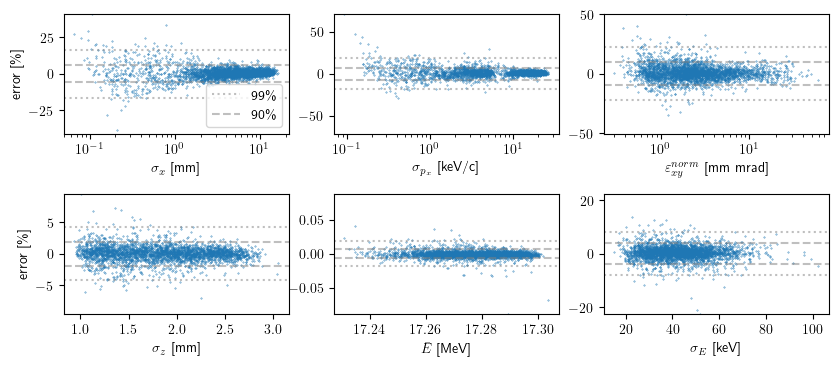

In [20]:
def show_and_save_rel_err_plots(
    tag: str,
    results: pd.DataFrame,
):

    n = len(y_params)
    cols = math.ceil(math.sqrt(n))
    rows = math.ceil(n / cols)

    fig, axs = plt.subplots(rows, cols, figsize=(3 * cols, 2 * rows))
    plt.subplots_adjust(
        left=0.1, right=0.95, top=0.95, bottom=0.2, hspace=0.5, wspace=0.2
    )

    for i, ax, y in zip(range(len(axs.flatten())), axs.flatten(), y_params):
        y_rel_err = f"{y} rel. error"
        if i % cols == 0:
            ax.set_ylabel(r"error [\%]")
        ax.set_xlabel(axis_label(y))
        ax.set_xscale(scale_type.get(y, "linear"))
        ax.scatter(
            results[y] * scaling_factor.get(y, 1),
            results[y_rel_err] * 100,
            s=0.1,
            # c=results["gun_B_max"],
            # cmap="viridis",
        )
        lim = results[y_rel_err].abs().max() * 100
        ax.set_ylim(-lim, lim)
        # percentiles
        for p, c, s in zip([1, 10], ["grey", "grey", "grey"], [":", "--", "-"]):
            threshold = np.percentile(results[y_rel_err].abs() * 100, 100 - p)
            ax.axhline(threshold, color=c, linestyle=s, alpha=0.5, label=f"{100-p}\%")
            ax.axhline(-threshold, color=c, linestyle=s, alpha=0.5)
        if i == 0:
            ax.legend()

    fig.savefig(
        f"{best_version_path}/eval/{tag}{'_' if tag else ''}rel_err_overview.pdf"
    )
    plt.show()


show_and_save_rel_err_plots(
    tag="",
    results=results,
)

# Application: Find Optimal Output


In [21]:
def get_optimum_for(
    y_param: str,
    x_min: float = -1.0,
    x_max: float = 1.0,
    learning_rate: float = 0.05,
    steps: int = 100,
):

    lower = torch.full((x_size,), x_min)
    upper = torch.full((x_size,), x_max)

    x = torch.rand(x_size, requires_grad=True)
    optimizer = torch.optim.Adam([x], lr=learning_rate)

    for _ in range(steps):
        optimizer.zero_grad()

        loss = model(x)[y_params.index(y_param)]
        loss.backward()
        optimizer.step()

        # projection onto hypercube
        with torch.no_grad():
            x.clamp_(lower, upper)

    y = model(x).detach()

    x_optim = back_trafo_x(x.unsqueeze(0)).squeeze(0)
    y_optim = back_trafo_y(y.unsqueeze(0)).squeeze(0)
    x_optim = pd.Series({p: x_optim[i].item() for i, p in enumerate(x_params)})
    y_optim = pd.Series({p: y_optim[i].item() for i, p in enumerate(y_params)})

    return x_optim, y_optim


y_optimize_for = "norm_emit_x-final"
x_optim, y_optim = get_optimum_for(
    y_optimize_for,
    learning_rate=1e-3,
    steps=10_000,
)
print("x*")
print(x_optim)
print("f(x*)")
print(y_optim)

x*
latent vector component 00   -1.138153
latent vector component 01   -0.780523
latent vector component 02   -1.358396
latent vector component 03    0.718698
latent vector component 04    0.779998
latent vector component 05    0.526253
latent vector component 06    0.807896
latent vector component 07   -0.440617
latent vector component 08    0.811743
latent vector component 09   -0.785495
latent vector component 10    1.246610
latent vector component 11   -0.855156
latent vector component 12    1.091760
latent vector component 13    1.085590
latent vector component 14    0.972721
latent vector component 15   -0.929541
latent vector component 16   -1.635633
latent vector component 17   -0.813841
latent vector component 18   -0.160133
latent vector component 19   -0.780290
latent vector component 20   -1.221993
latent vector component 21    0.052673
latent vector component 22    0.724618
latent vector component 23   -0.971532
latent vector component 24   -0.947016
latent vector componen

In [22]:
def show_wiggle_plot(
    wiggle_x_param: str,
    y_param: str,
    x_delta: float = 0.5,
    x_divs: int = 100,
):

    wiggle_table = pd.DataFrame()
    for delta in np.linspace(-x_delta, x_delta, x_divs):
        x = torch.tensor(x_optim.to_list())
        x[x_params.index(wiggle_x_param)] += delta

        x = trafo_x(x.unsqueeze(0)).squeeze(0)
        y = model(x).detach()

        x = back_trafo_x(x.unsqueeze(0)).squeeze(0)
        y = back_trafo_y(y.unsqueeze(0)).squeeze(0)

        x = pd.Series({p: x[i].item() for i, p in enumerate(x_params)})
        y = pd.Series({p: y[i].item() for i, p in enumerate(y_params)})

        row = pd.concat([x, y]).to_frame().T.copy()
        wiggle_table = pd.concat([wiggle_table, row], ignore_index=True)

    fig = px.line(wiggle_table, x=wiggle_x_param, y=y_param)
    fig.add_scatter(
        x=[x_optim[wiggle_x_param]],
        y=[y_optim[y_param]],
        mode="markers",
        marker=dict(color="red", size=10),
        name="x*",
    )
    fig.update_layout(
        title=f"wiggle plot for {y_param} over {wiggle_x_param}",
        width=600,
        height=600,
    )
    fig.show()


show_wiggle_plot(
    wiggle_x_param="latent vector component 16",
    y_param=y_optimize_for,
    x_divs=1_000,
)

In [23]:
def show_wiggle_plot_2d(
    wiggle_x_param1: str,
    wiggle_x_param2: str,
    y_param: str,
    x_delta: float = 0.5,
    x_divs: int = 100,
):

    wiggle_table = pd.DataFrame()
    for delta1 in np.linspace(-x_delta, x_delta, x_divs):
        for delta2 in np.linspace(-x_delta, x_delta, x_divs):

            x = torch.tensor(x_optim.to_list())
            x = trafo_x(x.unsqueeze(0)).squeeze(0)

            x[x_params.index(wiggle_x_param1)] += delta1
            x[x_params.index(wiggle_x_param2)] += delta2

            y = model(x).detach()

            x = back_trafo_x(x.unsqueeze(0)).squeeze(0)
            y = back_trafo_y(y.unsqueeze(0)).squeeze(0)

            x = pd.Series({p: x[i].item() for i, p in enumerate(x_params)})
            y = pd.Series({p: y[i].item() for i, p in enumerate(y_params)})

            row = pd.concat([x, y]).to_frame().T.copy()
            wiggle_table = pd.concat([wiggle_table, row], ignore_index=True)

    matrix = wiggle_table.pivot(
        index=wiggle_x_param1, columns=wiggle_x_param2, values=y_param
    )
    fig = px.imshow(
        matrix,
        labels=dict(
            color=y_param,
        ),
    )
    fig.add_scatter(
        x=[x_optim[wiggle_x_param2]],
        y=[x_optim[wiggle_x_param1]],
        mode="markers",
        marker=dict(color="red", size=10),
        name="x*",
    )
    fig.update_layout(
        title=f"wiggle plot for {y_param} over {wiggle_x_param1} and {wiggle_x_param2}",
        width=600,
        height=600,
    )
    fig.show()

    fig.write_image(
        f"{best_version_path}/eval/wiggle_plot_2d_{y_param}_over_{wiggle_x_param1}_and_{wiggle_x_param2}.pdf"
    )


show_wiggle_plot_2d(
    wiggle_x_param1="latent vector component 16",
    wiggle_x_param2="latent vector component 25",
    y_param=y_optimize_for,
    x_delta=0.5,
    x_divs=100,
)

In [24]:
show_wiggle_plot_2d(
    wiggle_x_param1="latent vector component 16",
    wiggle_x_param2="gun_phase",
    y_param=y_optimize_for,
    x_delta=0.5,
    x_divs=100,
)

In [25]:
show_wiggle_plot_2d(
    wiggle_x_param1="gun_B_max",
    wiggle_x_param2="gun_phase",
    y_param=y_optimize_for,
    x_delta=0.5,
    x_divs=100,
)

# Comparison with k-NNI Model


In [26]:
nn_model = NearestNeighboursInterpolationModel(
    x=data_train["x"], y=data_train["y"], k=32
)

In [27]:
nn_results = make_results(nn_model, data)

In [28]:
make_abs_rel_error_threshold_table("nn", nn_results)

,std_x-final abs. rel. error,std_px-final abs. rel. error,norm_emit_x-final abs. rel. error,std_z-final abs. rel. error,mean_kinetic_energy-final abs. rel. error,std_kinetic_energy-final abs. rel. error,threshold (%)
C1,8.111702,5.585106,13.031915,43.617021,100.0,41.223404,10.0
C2,6.382979,6.648936,12.500000,39.095745,100.0,41.090426,10.0
C3,4.661017,6.355932,12.711864,34.745763,100.0,34.322034,10.0
C4,8.333333,4.259259,10.740741,35.000000,100.0,34.629630,10.0
C5,8.027523,13.302752,18.348624,45.871560,100.0,40.825688,10.0
C6,7.349666,9.799555,18.262806,53.897550,100.0,45.211581,10.0
all,7.361769,7.330174,13.965245,42.180095,100.0,40.063191,10.0


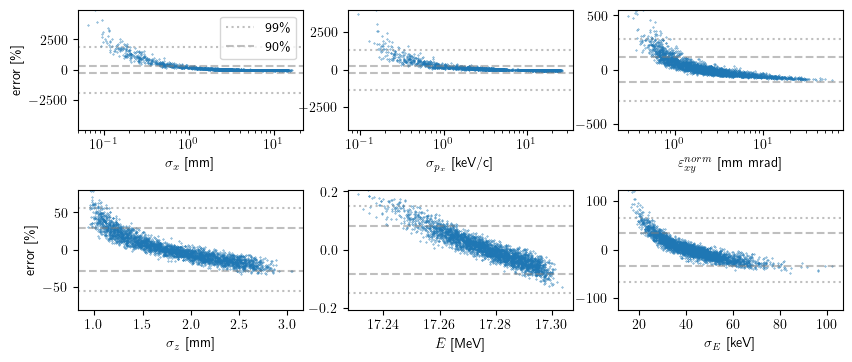

In [29]:
show_and_save_rel_err_plots(tag="nn", results=nn_results)

In [30]:
knni_results = {}
for k in tqdm([1, 2, 4, 8, 16, 32, 64, 128]):
    knni_model = NearestNeighboursInterpolationModel(
        x=data_train["x"], y=data_train["y"], k=k
    )
    knni_results[k] = make_results(knni_model, data)

100%|██████████| 8/8 [00:27<00:00,  3.48s/it]


In [31]:
def show_knni_threshold_precision_plot():
    table = pd.DataFrame()
    for k in knni_results.keys():
        df = make_abs_rel_error_threshold_table("knni", knni_results[k])
        df["k"] = k
        table = pd.concat([table, df])

    px.line(
        table.loc["all"].round(1),
        x="k",
        y=[col for col in table.columns if col not in ["k", "threshold (%)"]],
        title=f"fraction of k-NNI model predictions with less than {table['threshold (%)'].iloc[0]}% abs. rel. error vs. k",
        labels={"value": "fraction of predictions (%)", "variable": ""},
        log_x=True,
        log_y=True,
    ).show()


show_knni_threshold_precision_plot()

In [32]:
def show_knni_mean_precision_plot():
    table = pd.DataFrame()
    for k in knni_results.keys():
        df = make_abs_rel_error_mean_table("knni", knni_results[k])
        df["k"] = k
        table = pd.concat([table, df])

    px.line(
        table.loc["all"],
        x="k",
        y=[col for col in table.columns if col not in ["k", "threshold (%)"]],
        title=f"mean k-NNI model abs. rel. error vs. k",
        labels={"value": "mean abs. rel. error", "variable": ""},
        log_x=True,
        log_y=True,
    ).show()

    display(table.round(3))


show_knni_mean_precision_plot()

,std_x-final abs. rel. error,std_px-final abs. rel. error,norm_emit_x-final abs. rel. error,std_z-final abs. rel. error,mean_kinetic_energy-final abs. rel. error,std_kinetic_energy-final abs. rel. error,k
C1,183.611,185.379,94.882,19.994,0.057,21.709,1
C2,245.333,213.433,129.064,22.147,0.062,24.405,1
C3,156.612,194.663,65.185,19.653,0.056,23.182,1
C4,264.114,243.968,143.292,22.364,0.066,23.825,1
C5,169.638,129.319,73.490,15.875,0.048,22.101,1
C6,175.606,121.952,86.335,14.879,0.046,18.598,1
all,206.937,186.012,104.889,19.591,0.057,22.433,1
C1,164.831,152.449,68.382,16.146,0.047,18.345,2
C2,202.027,162.193,88.214,18.707,0.054,20.667,2
C3,154.761,137.205,64.407,15.855,0.049,19.609,2


## GMM shapes


In [33]:
def cmap(n):
    return px.colors.sample_colorscale("Turbo", [i / n for i in range(n)])

In [34]:
mean_shapes_df = np.load("data/external/shape_cluser_means.npz")
mean_shapes_df = pd.DataFrame(
    mean_shapes_df["shapes"].T,
    columns=mean_shapes_df["labels"],
    index=mean_shapes_df["time"],
)
mean_shapes_df.index.name = "time [ps]"
fig = px.line(
    mean_shapes_df,
    y=mean_shapes_df.columns,
    title="GMM shapes",
)
for trace, c in zip(fig.data, cmap(len(fig.data))):
    trace.line.color = c
fig.show()

In [35]:
mean_lat_vecs_df = np.load("data/external/shape_cluser_means.npz")
mean_lat_vecs_df = pd.DataFrame(
    mean_lat_vecs_df["latent_vecs"].T,
    columns=mean_lat_vecs_df["labels"],
)
fig = px.bar(
    mean_lat_vecs_df,
    y=mean_lat_vecs_df.columns,
    barmode="group",
    title="latent vector components of GMMs",
)
for trace, c in zip(fig.data, cmap(len(fig.data))):
    trace.marker.color = c
fig.update_layout(bargap=0.6, bargroupgap=0.0)
fig.show()

In [250]:
mean_lat_vecs_pca = np.load("data/external/shape_pca_components.npy").T
print(np.linalg.norm(mean_lat_vecs_pca, axis=0))
px.imshow(
    mean_lat_vecs_pca.T,
    labels=dict(x="latent space dimension", y="principal component", color="Value"),
    title="PCA of latent space GMMs",
    color_continuous_scale="RdBu",
    color_continuous_midpoint=0,
).show()

[1. 1.]


In [332]:
cluster_id_cmap = defaultdict(lambda: "rgb(255,0,0)") | dict(
    zip(mean_lat_vecs_df.columns, cmap(len(mean_lat_vecs_df.columns)))
)
markers = [
    "circle",
    "square",
    "diamond",
    "cross",
    "x",
    "triangle-up",
    "triangle-down",
    "triangle-left",
    "triangle-right",
]
cluster_id_marker_map = defaultdict(lambda: "star") | dict(
    zip(mean_lat_vecs_df.columns, markers)
)


markers_plt = [
    "o",
    "s",
    "D",
    "P",
    "X",
    "^",
    "v",
    "<",
    ">",
]
cluster_id_marker_map_plt = defaultdict(lambda: "*") | dict(
    zip(mean_lat_vecs_df.columns, markers_plt)
)

# Get Optimum


In [38]:
def _to_label_and_array(c):
    z = mean_lat_vecs_df[c]
    return z.name, z.to_numpy()


mean_lat_vec: dict = dict(map(_to_label_and_array, mean_lat_vecs_df.columns))

!!! WARNING A SINGLE RUN OF THIS ALGORITHM IS NOT ENOUGH TO GET A GOOD OPTIMUM. RUN IT MULTIPLE TIMES AND PICK THE BEST RESULT. !!!

In [45]:
def get_optimum_for_with_fixed(
    y_param: str,
    x_fixed: list[float | None],
    x_min: float | list[float] = -1.0,
    x_max: float | list[float] = 1.0,
    learning_rate: float = 0.05,
    steps: int = 100,
):

    assert len(x_fixed) <= x_size

    x_free_size = x_size - sum(1 for c in x_fixed if c is not None)

    # lower
    if np.isscalar(x_min):
        lower = torch.full(
            (x_free_size,),
            x_min,
            requires_grad=False,
        )
    elif isinstance(x_min, list):
        assert len(x_min) == x_free_size
        lower = torch.tensor(x_min, requires_grad=False)
    else:
        raise ValueError(
            "x_min must be a scalar or a list of the same length as the number of free variables."
        )

    # upper
    if np.isscalar(x_max):
        upper = torch.full(
            (x_free_size,),
            x_max,
            requires_grad=False,
        )
    elif isinstance(x_max, list):
        assert len(x_max) == x_free_size
        upper = torch.tensor(x_max, requires_grad=False)
    else:
        raise ValueError(
            "x_max must be a scalar or a list of the same length as the number of free variables."
        )

    x_free = torch.rand(x_free_size, requires_grad=False) * (upper - lower) + lower
    x_free = x_free.detach().clone().requires_grad_(True)
    optimizer = torch.optim.Adam([x_free], lr=learning_rate)

    def embed(x_free: torch.Tensor) -> torch.Tensor:
        x_full = torch.zeros(x_size)
        j = 0
        for i in range(x_size):
            if i < len(x_fixed) and x_fixed[i] is not None:
                x_full[i] = float(x_fixed[i])
            else:
                x_full[i] = x_free[j]
                j += 1
        return x_full

    def extract(x_full: torch.Tensor) -> torch.Tensor:
        x_free = torch.zeros(x_free_size)
        j = 0
        for i in range(x_size):
            if i < len(x_fixed) and x_fixed[i] is not None:
                continue
            else:
                x_free[j] = x_full[i]
                j += 1
        return x_free

    for _ in range(steps):
        optimizer.zero_grad()

        x = embed(x_free)
        loss = model(x)[y_params.index(y_param)]
        loss.backward()
        optimizer.step()

        # projection onto hypercube
        with torch.no_grad():
            x_free.clamp_(lower, upper)

    x = embed(x_free)
    y = model(x).detach()

    x_optim = back_trafo_x(x.unsqueeze(0)).squeeze(0)
    y_optim = back_trafo_y(y.unsqueeze(0)).squeeze(0)
    x_optim = pd.Series({p: x_optim[i].item() for i, p in enumerate(x_params)})
    y_optim = pd.Series({p: y_optim[i].item() for i, p in enumerate(y_params)})

    return x_optim, y_optim


cluster_id_optim = "C4"
lat_vec = mean_lat_vec[cluster_id_optim]  # flattop
x_optim, y_optim = get_optimum_for_with_fixed(
    y_optimize_for,
    x_fixed=list(lat_vec) + [None] * (x_size - len(lat_vec)),
    learning_rate=1e-3,
    steps=10_000,
)
print("x*")
print(x_optim)
print("f(x*)")
print(y_optim)

x*
latent vector component 00   -0.348042
latent vector component 01   -0.231854
latent vector component 02   -1.044139
latent vector component 03    0.408141
latent vector component 04   -0.387509
latent vector component 05   -0.734940
latent vector component 06   -0.011331
latent vector component 07    0.254387
latent vector component 08    0.012444
latent vector component 09   -0.147793
latent vector component 10    0.437653
latent vector component 11    0.078608
latent vector component 12    0.741238
latent vector component 13    0.557817
latent vector component 14    0.554793
latent vector component 15   -0.167769
latent vector component 16   -2.421935
latent vector component 17    0.393861
latent vector component 18    0.037499
latent vector component 19    0.237210
latent vector component 20   -0.755672
latent vector component 21   -1.065279
latent vector component 22   -0.044871
latent vector component 23   -0.780974
latent vector component 24   -0.161991
latent vector componen

# Application: Estimate Overall Optimum

In [47]:
raise RuntimeError("stop. execute either calculation or loading manually")

RuntimeError: stop. execute either calculation or loading manually

In [ ]:
tqdm.pandas()


def estimate_global_optimum(y_optimize_for: str, n: int = 1) -> pd.Series:
    opts = pd.DataFrame(range(n), columns=["opt_id"])

    def opt(_):
        x, y = get_optimum_for_with_fixed(
            y_optimize_for,
            x_fixed=[None] * x_size,
            x_min=-3,
            x_max=3,
            learning_rate=1e-3,
            steps=10_000,
        )
        return pd.concat([x, y])

    opts[x_params + y_params] = opts.progress_apply(
        opt,
        axis=1,
    )

    return (
        opts.sort_values(by=y_optimize_for)
        .reset_index(drop=True)
        .drop(columns=["opt_id"])
    )


opts = estimate_global_optimum(y_optimize_for, n=100)
print(len(opts))
opts[:1]

In [ ]:
# save
opts.to_csv(
    f"{best_version_path}/eval/global_optimum_estimation_{y_optimize_for}.csv",
    index=False,
)

In [ ]:
# load
opts = pd.read_csv(
    f"{best_version_path}/eval/global_optimum_estimation_{y_optimize_for}.csv",
)
print(len(opts))
opts[:1]

100


,latent vector component 00,latent vector component 01,latent vector component 02,latent vector component 03,latent vector component 04,latent vector component 05,latent vector component 06,latent vector component 07,latent vector component 08,latent vector component 09,...,gun_phase,gun_B_max,bunch_initial_xy_rms,bunch_initial_t_rms,std_x-final,std_px-final,norm_emit_x-final,std_z-final,mean_kinetic_energy-final,std_kinetic_energy-final
0,2.773571,-0.741166,2.096544,2.494262,2.461628,2.185107,1.30599,-2.069051,-2.300031,-2.306167,...,-0.625481,0.205774,0.181448,0.008897,0.000172,3007.239014,1.409719e-07,0.002276,17267356.0,39678.277344


In [49]:
px.scatter(
    opts,
    y=y_optimize_for,
    x="latent vector component 16",
    color="gun_B_max",
    color_continuous_scale="viridis",
)

In [50]:
px.bar(opts.iloc[0][opts.columns.str.startswith("latent vector component")]).show()

# Application: Get Optimum for given Shape

In [51]:
def make_optimal_x_per_shape_cluster_table(
    lat_vec_df: pd.DataFrame,
    lat_vec_cluster_ids: list[str],
    y_optimize_for: str,
):

    assert len(lat_vec_cluster_ids) == len(lat_vec_df.columns)

    df = pd.DataFrame()
    for i, c in enumerate(tqdm(lat_vec_df.columns)):
        lat_vec = lat_vec_df[c]
        x_optim, y_optim = get_optimum_for_with_fixed(
            y_optimize_for,
            x_fixed=list(lat_vec) + [None] * (x_size - len(lat_vec)),
            x_min=-3,
            x_max=3,
            learning_rate=1e-3,
            steps=10_000,
        )

        # append cluster id
        x_optim["laser_pulse_shape_cluster_id"] = lat_vec_cluster_ids[i]

        row = pd.concat([x_optim, y_optim])
        row.name = c

        df = pd.concat([df, row.to_frame().T])

        df = df.apply(pd.to_numeric, errors="ignore")

    return df


opt_per_shape_cluster_table = make_optimal_x_per_shape_cluster_table(
    mean_lat_vecs_df,
    mean_lat_vecs_df.columns.tolist(),
    y_optimize_for,
)
opt_per_shape_cluster_table

100%|██████████| 6/6 [00:57<00:00,  9.63s/it]


,latent vector component 00,latent vector component 01,latent vector component 02,latent vector component 03,latent vector component 04,latent vector component 05,latent vector component 06,latent vector component 07,latent vector component 08,latent vector component 09,...,gun_B_max,bunch_initial_xy_rms,bunch_initial_t_rms,laser_pulse_shape_cluster_id,std_x-final,std_px-final,norm_emit_x-final,std_z-final,mean_kinetic_energy-final,std_kinetic_energy-final
C1,-0.448861,-0.047682,-0.574227,-0.034131,0.489416,-0.748467,-0.026282,0.770860,0.325063,0.061904,...,0.211948,0.238336,0.008745,C1,0.000224,1580.549072,3.852579e-07,0.002444,17265254.0,50555.675781
C2,-0.382181,0.008511,-0.562340,-0.384011,0.031136,-0.431601,0.293131,0.473120,-0.001744,-0.024503,...,0.199455,0.159327,0.008394,C2,0.000763,4638.371582,5.755389e-07,0.002421,17266016.0,51179.132812
C3,0.739962,-0.933500,-0.383748,-0.153436,-0.447867,-0.260197,0.261186,0.271962,0.083650,-0.085793,...,0.244474,0.157783,0.002038,C3,0.005902,14443.449219,1.323985e-06,0.001208,17292842.0,22433.732422
C4,-0.348042,-0.231854,-1.044139,0.408141,-0.387509,-0.734940,-0.011331,0.254387,0.012444,-0.147793,...,0.214498,0.202408,0.001698,C4,0.000564,5231.754395,5.834677e-07,0.001163,17281212.0,26217.738281
C5,0.073538,-0.235533,-0.412338,-0.722541,-0.052284,0.013642,0.356108,0.450243,-0.154227,0.058603,...,0.238451,0.172114,0.006353,C5,0.004918,13508.366211,1.369778e-06,0.002077,17275736.0,38517.957031
C6,-0.157627,0.051430,-0.821146,-0.085913,0.036078,-0.168579,0.150264,0.317988,0.009822,-0.112022,...,0.214518,0.270032,0.002731,C6,0.000417,3323.346436,6.445337e-07,0.001177,17294664.0,49846.941406


In [52]:
inverted_parabola_lat_vecs = pd.read_csv(
    "data/external/inverted_parabola_lat_vecs.csv"
).T

inverted_parabola_lat_vecs.columns = [
    f"IP-{i}" for i in range(inverted_parabola_lat_vecs.shape[1])
]

# select alpha=1/3
inverted_parabola_lat_vecs = inverted_parabola_lat_vecs[["IP-3"]]

print(inverted_parabola_lat_vecs.shape)
inverted_parabola_lat_vecs

(32, 1)


,IP-3
latent vector component 00,0.684461
latent vector component 01,-0.296821
latent vector component 02,-1.646647
latent vector component 03,1.078105
latent vector component 04,0.818795
latent vector component 05,-1.003675
latent vector component 06,-0.794361
latent vector component 07,2.678091
latent vector component 08,-0.690972
latent vector component 09,-1.991570


In [53]:
opt_per_shape_cluster_table2 = make_optimal_x_per_shape_cluster_table(
    inverted_parabola_lat_vecs,
    ["IP"] * len(inverted_parabola_lat_vecs.columns),
    y_optimize_for,
)
opt_per_shape_cluster_table2

100%|██████████| 1/1 [00:09<00:00,  9.58s/it]


,latent vector component 00,latent vector component 01,latent vector component 02,latent vector component 03,latent vector component 04,latent vector component 05,latent vector component 06,latent vector component 07,latent vector component 08,latent vector component 09,...,gun_B_max,bunch_initial_xy_rms,bunch_initial_t_rms,laser_pulse_shape_cluster_id,std_x-final,std_px-final,norm_emit_x-final,std_z-final,mean_kinetic_energy-final,std_kinetic_energy-final
IP-3,0.509133,-0.390308,-1.916927,0.788038,0.627638,-1.135649,-0.412306,2.554148,-0.503738,-1.539421,...,0.231932,0.156323,0.0103,IP,0.003199,10565.480469,0.000001,0.002788,17255636.0,57065.765625


In [54]:
def make_opt_by_param_plot(
    opt_table: pd.DataFrame,
    y_optimize_for: str,
    show_x_param: str,
    save: bool = True,
    x_log: bool = False,
    y_log: bool = False,
    file_name_suffix: str = "",
):
    fig = go.Figure()
    for cluster_id, df in opt_table.groupby("laser_pulse_shape_cluster_id"):
        fig.add_trace(
            go.Scatter(
                x=df[show_x_param],
                y=df[y_optimize_for],
                mode="markers",
                name=cluster_id,
                marker=dict(
                    size=7,
                    color=cluster_id_cmap[cluster_id],
                    line=dict(color="black", width=1),
                ),
            )
        )
        fig.update_layout(
            title=f"optimal {y_optimize_for} vs. {show_x_param} per laser pulse shape cluster NOTE: ALGORITHM NOT STABLE!!",
            xaxis_title=show_x_param,
            yaxis_title=y_optimize_for,
        )
        fig.update_xaxes(type="log" if x_log else "linear")
        fig.update_yaxes(type="log" if y_log else "linear")

    if save:
        fig.write_image(
            f"{best_version_path}/eval/opt_{y_optimize_for}_vs_{show_x_param}{file_name_suffix}.pdf"
        )

    return fig


make_opt_by_param_plot(
    opt_per_shape_cluster_table,
    y_optimize_for,
    "std_z-final",
    x_log=True,
    save=False,
).show()

In [55]:
make_opt_by_param_plot(
    pd.concat([opt_per_shape_cluster_table, opt_per_shape_cluster_table2]),
    y_optimize_for,
    "std_z-final",
    x_log=True,
    save=False,
).show()

## Optima for Cluster Means + Noise


In [56]:
def augment_with_noise(df, n=1, noise_std=1):
    """
    Create n copies of each row in df and add Gaussian noise to numerical columns.

    Parameters:
    - df: pandas DataFrame
    - n: number of copies per row
    - noise_std: standard deviation of Gaussian noise relative to each value

    Returns:
    - augmented DataFrame
    """
    # identify numerical columns
    num_cols = df.select_dtypes(include=[np.number]).columns

    # repeat each row n times
    df_repeated = pd.DataFrame(np.repeat(df.values, n, axis=0), columns=df.columns)

    # add Gaussian noise to numerical columns
    for col in num_cols:
        noise = np.random.normal(loc=0, scale=noise_std, size=df_repeated.shape[0])
        df_repeated[col] = df_repeated[col].astype(float) + noise

    return df_repeated


# example
df = pd.DataFrame(
    {
        "A": [1, 2, 3],
        "B": [10, 20, 30],
        "C": ["x", "y", "z"],
    }
)

augment_with_noise(df, n=3, noise_std=0.5)

,A,B,C
0,0.926411,9.602876,x
1,0.656812,10.268095,x
2,0.840465,10.000442,x
3,2.479693,20.452010,y
4,2.212280,20.418352,y
5,2.096678,20.643823,y
6,3.488468,29.640752,z
7,2.660493,30.349546,z
8,2.360531,30.286525,z


In [57]:
def augment_columns_with_noise(df, n=1, noise_std=1):
    """
    Create n copies of each column in df and add Gaussian noise to numerical columns.

    Parameters:
    - df: pandas DataFrame
    - n: number of copies per column
    - noise_std: standard deviation of Gaussian noise relative to each value

    Returns:
    - augmented DataFrame with more columns
    """
    num_cols = df.select_dtypes(include=[np.number]).columns
    augmented_data = {}

    for col in df.columns:
        for i in range(n):
            new_col_name = f"{col}-{i+1}"
            if col in num_cols:
                # add Gaussian noise
                augmented_data[new_col_name] = df[col].astype(float) + np.random.normal(
                    0, noise_std, size=len(df)
                )
            else:
                # just replicate non-numeric column
                augmented_data[new_col_name] = df[col]

    return pd.DataFrame(augmented_data)


# example
df = pd.DataFrame(
    {
        "A": [1, 2, 3],
        "B": [10, 20, 30],
        "C": ["x", "y", "z"],
    }
)

augment_columns_with_noise(df, n=3, noise_std=0.5)

,A-1,A-2,A-3,B-1,B-2,B-3,C-1,C-2,C-3
0,0.583901,1.088188,1.330338,10.793247,10.651268,10.310861,x,x,x
1,1.947203,1.740433,1.382300,18.790622,20.524136,19.792479,y,y,y
2,3.389352,2.094506,2.658346,29.492039,30.077580,30.886041,z,z,z


In [58]:
def noisify_lattent_vectors(lat_vec_df, n_variations: int = 1, noise_std: float = 1):

    return (
        augment_columns_with_noise(
            lat_vec_df,
            n=n_variations,
            noise_std=noise_std,
        ),
        [c for c in lat_vec_df.columns for _ in range(n_variations)],
    )


mean_lat_vecs_noise_std = 0.1
mean_lat_vecs_with_noise_df, mean_lat_vecs_with_noise_df_cluster_ids = (
    noisify_lattent_vectors(
        mean_lat_vecs_df,
        n_variations=100,
        noise_std=mean_lat_vecs_noise_std,
    )
)
# print(mean_lat_vecs_with_noise_df_cluster_ids)
# mean_lat_vecs_with_noise_df

In [59]:
ip_lat_vec_with_noise_df, ip_lat_vec_with_noise_cluster_ids = noisify_lattent_vectors(
    inverted_parabola_lat_vecs,
    n_variations=100,
    noise_std=mean_lat_vecs_noise_std,
)

In [60]:
raise RuntimeError(
    "WARNIG: Potentially expensive computation ahead. Consider loading cached data if applicable."
)

RuntimeError: WARNIG: Potentially expensive computation ahead. Consider loading cached data if applicable.

In [ ]:
# calculate
opt_per_shape_cluster_with_noise_table = make_optimal_x_per_shape_cluster_table(
    mean_lat_vecs_with_noise_df,
    mean_lat_vecs_with_noise_df_cluster_ids,
    y_optimize_for,
)

100%|██████████| 600/600 [1:34:48<00:00,  9.48s/it]


In [ ]:
opt_per_shape_cluster_with_noise_table2 = make_optimal_x_per_shape_cluster_table(
    ip_lat_vec_with_noise_df,
    ip_lat_vec_with_noise_cluster_ids,
    y_optimize_for,
)

100%|██████████| 100/100 [15:52<00:00,  9.52s/it]


In [ ]:
# cache in case of costly computation
opt_per_shape_cluster_with_noise_table.to_csv(
    f"{best_version_path}/eval/optimal_x_per_shape_cluster_with_noise_{mean_lat_vecs_noise_std}.csv",
    index=True,
)

In [ ]:
opt_per_shape_cluster_with_noise_table2.to_csv(
    f"{best_version_path}/eval/optimal_x_per_inverted_parabola_with_noise_{mean_lat_vecs_noise_std}.csv",
    index=True,
)

In [251]:
# load it back if cached
opt_per_shape_cluster_with_noise_table = pd.read_csv(
    f"{best_version_path}/eval/optimal_x_per_shape_cluster_with_noise_{mean_lat_vecs_noise_std}.csv",
    index_col=0,
)
opt_per_shape_cluster_with_noise_table = opt_per_shape_cluster_with_noise_table.apply(
    pd.to_numeric, errors="ignore"
)

In [252]:
# load it back if cached
opt_per_shape_cluster_with_noise_table2 = pd.read_csv(
    f"{best_version_path}/eval/optimal_x_per_inverted_parabola_with_noise_{mean_lat_vecs_noise_std}.csv",
    index_col=0,
)
opt_per_shape_cluster_with_noise_table2 = opt_per_shape_cluster_with_noise_table2.apply(
    pd.to_numeric, errors="ignore"
)

In [253]:
def filtered_opt_table(opt_table):
    mask = (opt_table["gun_B_max"] > 0.15) & (opt_table["gun_B_max"] < 0.3)
    print((~mask).sum(), "filtered")
    opt_table = opt_table[mask]

    return opt_table


opt_per_shape_cluster_with_noise_table = filtered_opt_table(
    opt_per_shape_cluster_with_noise_table
)
opt_per_shape_cluster_with_noise_table2 = filtered_opt_table(
    opt_per_shape_cluster_with_noise_table2
)

26 filtered
0 filtered


In [255]:
def append_pcs(
    opt_table: pd.DataFrame,
    pca: np.ndarray,
):
    pc_cols = [f"PC{i+1}" for i in range(pca.shape[0])]

    def f(row):
        z = row[
            [c for c in row.index if c.startswith("latent vector component")]
        ].values
        return pd.Series(pca @ z, index=pc_cols)

    opt_table[pc_cols] = opt_table.apply(f, axis=1)


append_pcs(opt_per_shape_cluster_with_noise_table, mean_lat_vecs_pca.T)

print(len(opt_per_shape_cluster_with_noise_table))
display(opt_per_shape_cluster_with_noise_table[:1])

574


,latent vector component 00,latent vector component 01,latent vector component 02,latent vector component 03,latent vector component 04,latent vector component 05,latent vector component 06,latent vector component 07,latent vector component 08,latent vector component 09,...,bunch_initial_t_rms,laser_pulse_shape_cluster_id,std_x-final,std_px-final,norm_emit_x-final,std_z-final,mean_kinetic_energy-final,std_kinetic_energy-final,PC1,PC2
C1-1,-0.348462,-0.084577,-0.46638,-0.118781,0.609699,-0.76939,-0.085002,0.757787,0.272007,0.098934,...,0.008913,C1,0.003767,11571.795898,0.000001,0.002526,17264006.0,48915.035156,-2.689118,-1.533834


In [257]:
append_pcs(opt_per_shape_cluster_with_noise_table2, mean_lat_vecs_pca.T)
print(len(opt_per_shape_cluster_with_noise_table2))
display(opt_per_shape_cluster_with_noise_table2[:1])

100


,latent vector component 00,latent vector component 01,latent vector component 02,latent vector component 03,latent vector component 04,latent vector component 05,latent vector component 06,latent vector component 07,latent vector component 08,latent vector component 09,...,bunch_initial_t_rms,laser_pulse_shape_cluster_id,std_x-final,std_px-final,norm_emit_x-final,std_z-final,mean_kinetic_energy-final,std_kinetic_energy-final,PC1,PC2
IP-3-1,0.645257,-0.498174,-1.978896,0.929343,0.540183,-1.016062,-0.447793,2.609387,-0.555457,-1.543193,...,0.006344,IP-3,0.004469,13042.933594,9.920182e-07,0.001951,17279358.0,34084.949219,-7.005342,1.9467


overall opt so far

In [317]:
opt = (
    pd.concat(
        [
            opt_per_shape_cluster_with_noise_table,
            opt_per_shape_cluster_with_noise_table2,
        ],
    )
    .convert_dtypes()
    .sort_values(by=y_optimize_for)
    .reset_index(drop=True)
    .iloc[0]
)
opt

latent vector component 00           0.5518
latent vector component 01        -0.228551
latent vector component 02        -1.838675
latent vector component 03         0.910256
latent vector component 04         0.518705
latent vector component 05        -1.175074
latent vector component 06        -0.472701
latent vector component 07          2.53865
latent vector component 08        -0.388034
latent vector component 09        -1.522019
latent vector component 10         1.727321
latent vector component 11         2.652544
latent vector component 12         0.516319
latent vector component 13        -1.362166
latent vector component 14         0.123369
latent vector component 15         0.761547
latent vector component 16        -3.802296
latent vector component 17         2.851307
latent vector component 18          1.03517
latent vector component 19        -0.345947
latent vector component 20         1.230093
latent vector component 21        -1.182626
latent vector component 22      

In [258]:
def show_opt_per_shape_lat_vec_with_noise_corr():
    for cluster_id, df in opt_per_shape_cluster_with_noise_table.groupby(
        "laser_pulse_shape_cluster_id"
    ):
        # mask = df["norm_emit_x-final"] > 1
        # df[mask]

        px.imshow(
            df.select_dtypes(include="number").corr().loc[y_params][x_params],
            color_continuous_scale="RdBu",
            zmin=-1,
            zmax=1,
            title=f"correlation matrix for {cluster_id}",
        ).show()


show_opt_per_shape_lat_vec_with_noise_corr()

In [259]:
make_opt_by_param_plot(
    pd.concat(
        [
            opt_per_shape_cluster_with_noise_table,
            opt_per_shape_cluster_with_noise_table2,
        ]
    ),
    y_optimize_for,
    "std_z-final",
    x_log=True,
    save=True,
    file_name_suffix=f"_noise_std_{mean_lat_vecs_noise_std}",
).show()

In [260]:
make_opt_by_param_plot(
    pd.concat(
        [
            opt_per_shape_cluster_with_noise_table,
            opt_per_shape_cluster_with_noise_table2,
        ]
    ),
    y_optimize_for,
    "PC1",
    save=True,
    file_name_suffix=f"_noise_std_{mean_lat_vecs_noise_std}",
).show()

In [261]:
make_opt_by_param_plot(
    pd.concat(
        [
            opt_per_shape_cluster_with_noise_table,
            opt_per_shape_cluster_with_noise_table2,
        ]
    ),
    y_optimize_for,
    "PC2",
    save=True,
    file_name_suffix=f"_noise_std_{mean_lat_vecs_noise_std}",
).show()

In [262]:
make_opt_by_param_plot(
    pd.concat(
        [
            opt_per_shape_cluster_with_noise_table,
            opt_per_shape_cluster_with_noise_table2,
        ]
    ),
    y_optimize_for,
    "latent vector component 16",
    save=True,
    file_name_suffix=f"_noise_std_{mean_lat_vecs_noise_std}",
).show()

In [263]:
make_opt_by_param_plot(
    pd.concat(
        [
            opt_per_shape_cluster_with_noise_table,
            opt_per_shape_cluster_with_noise_table2,
        ]
    ),
    y_optimize_for,
    "latent vector component 25",
    save=True,
    file_name_suffix=f"_noise_std_{mean_lat_vecs_noise_std}",
).show()

In [264]:
def show_opt_correlation_matrix():
    px.imshow(
        pd.concat(
            [
                opt_per_shape_cluster_with_noise_table,
                opt_per_shape_cluster_with_noise_table2,
            ]
        )
        .select_dtypes(include="number")
        .corr()
        .loc[y_params][x_params],
        color_continuous_scale="RdBu",
        zmin=-1,
        zmax=1,
        title=f"correlation matrix overall",
    ).show()


show_opt_correlation_matrix()

In [265]:
def make_opt_by_param_with_color_plot(
    opt_table: pd.DataFrame,
    y_optimize_for: str,
    show_x_param: str,
    color_param: str,
    save: bool = True,
    x_log: bool = False,
    y_log: bool = False,
    file_name_suffix: str = "",
):
    fig = go.Figure()
    for i, (cluster_id, df) in enumerate(
        opt_table.groupby("laser_pulse_shape_cluster_id")
    ):
        # symbol by cluster_id_marker_map
        fig.add_trace(
            go.Scatter(
                x=df[show_x_param],
                y=df[y_optimize_for],
                marker=dict(
                    color=df[color_param],
                    cmin=opt_table[color_param].min(),
                    cmax=opt_table[color_param].max(),
                    colorscale="Viridis",
                    colorbar=dict(title=color_param),
                    showscale=i == 0,  # only show color scale for first trace
                    symbol=cluster_id_marker_map[cluster_id],
                ),
                mode="markers",
                name=cluster_id,
            )
        )

    fig.update_layout(
        title=f"optimal {y_optimize_for} vs. {show_x_param} colored by {color_param}",
        xaxis_title=show_x_param,
        yaxis_title=y_optimize_for,
        # move legend outside plot
        legend=dict(
            title="laser pulse shape cluster",
            x=0.01,
            y=-0.1,
            yanchor="top",
            xanchor="left",
        ),
    )
    fig.update_xaxes(type="log" if x_log else "linear")
    fig.update_yaxes(type="log" if y_log else "linear")

    if save:
        fig.write_image(
            f"{best_version_path}/eval/opt_{y_optimize_for}_vs_{show_x_param}_cmap_{color_param}{file_name_suffix}.pdf"
        )

    return fig


make_opt_by_param_with_color_plot(
    pd.concat(
        [
            opt_per_shape_cluster_with_noise_table,
            opt_per_shape_cluster_with_noise_table2,
        ]
    ),
    y_optimize_for,
    "PC1",
    color_param="bunch_initial_xy_rms",
    y_log=True,
    save=False,
).show()

In [266]:
make_opt_by_param_with_color_plot(
    pd.concat(
        [
            opt_per_shape_cluster_with_noise_table,
            opt_per_shape_cluster_with_noise_table2,
        ]
    ),
    y_optimize_for,
    "PC1",
    color_param="gun_B_max",
    y_log=True,
    save=True,
).show()

(<Figure size 400x300 with 2 Axes>,
 <Axes: xlabel='PC1', ylabel='$\\varepsilon^{norm}_{xy}$ [mm~mrad]'>)

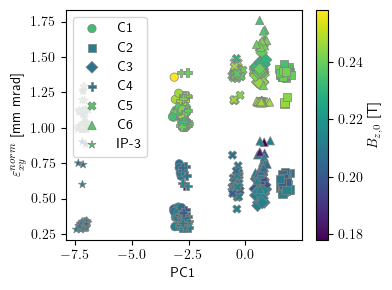

In [ ]:
def show_and_save_opt_by_param_with_color_plot(
    opt_table: pd.DataFrame,
    y_optimize_for: str,
    show_x_param: str,
    color_param: str,
    save: bool = True,
    x_log: bool = False,
    y_log: bool = False,
    file_name_suffix: str = "",
):
    fig, ax = plt.subplots(figsize=(4, 3))

    # global color limits (same as Plotly cmin/cmax)
    vmin = opt_table[color_param].min() * scaling_factor.get(color_param, 1)
    vmax = opt_table[color_param].max() * scaling_factor.get(color_param, 1)

    scatter_for_colorbar = None

    for i, (cluster_id, df) in enumerate(
        opt_table.groupby("laser_pulse_shape_cluster_id")
    ):

        sc = ax.scatter(
            df[show_x_param] * scaling_factor.get(show_x_param, 1),
            df[y_optimize_for] * scaling_factor.get(y_optimize_for, 1),
            c=df[color_param] * scaling_factor.get(color_param, 1),
            vmin=vmin,
            vmax=vmax,
            cmap="viridis",
            marker=cluster_id_marker_map_plt[cluster_id],
            label=cluster_id,
            edgecolors="gray",
            linewidths=0.5,
        )

        # keep one handle for colorbar
        if scatter_for_colorbar is None:
            scatter_for_colorbar = sc

    # axes labels
    ax.set_xlabel(axis_label(show_x_param))
    ax.set_ylabel(axis_label(y_optimize_for))

    # log scaling
    if x_log:
        ax.set_xscale("log")
    if y_log:
        ax.set_yscale("log")

    # legend
    ax.legend(
        #     title="laser pulse shape cluster",
        #     loc="upper left",
        #     bbox_to_anchor=(0.01, -0.1),
    )

    # colorbar
    cbar = fig.colorbar(scatter_for_colorbar, ax=ax)
    cbar.set_label(axis_label(color_param))

    fig.tight_layout()

    if save:
        fig.savefig(
            f"{best_version_path}/eval/opt_{y_optimize_for}_vs_{show_x_param}_cmap_{color_param}{file_name_suffix}_2.pdf"
        )

    return fig, ax


show_and_save_opt_by_param_with_color_plot(
    pd.concat(
        [
            opt_per_shape_cluster_with_noise_table,
            opt_per_shape_cluster_with_noise_table2,
        ]
    ),
    y_optimize_for,
    "PC1",
    color_param="gun_B_max",
    # y_log=True,
    save=True,
)

(<Figure size 400x300 with 2 Axes>,
 <Axes: xlabel='PC2', ylabel='$\\varepsilon^{norm}_{xy}$ [mm~mrad]'>)

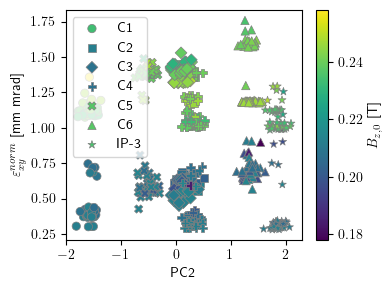

In [268]:
show_and_save_opt_by_param_with_color_plot(
    pd.concat(
        [
            opt_per_shape_cluster_with_noise_table,
            opt_per_shape_cluster_with_noise_table2,
        ]
    ),
    y_optimize_for,
    "PC2",
    color_param="gun_B_max",
    # y_log=True,
    save=True,
)

(<Figure size 400x300 with 2 Axes>, <Axes: xlabel='PC1', ylabel='PC2'>)

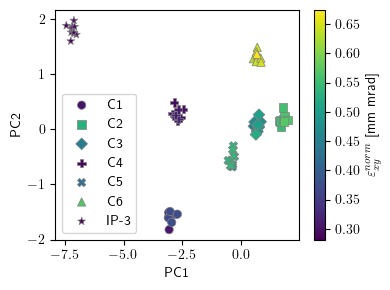

In [ ]:
def top_n_per_shape(table, n: int = 1):

    def f(id, df):
        return df.sort_values(by=y_optimize_for).head(n)

    return pd.concat(
        list(
            map(
                lambda x: f(*x),
                table.groupby("laser_pulse_shape_cluster_id"),
            )
        )
    )


show_and_save_opt_by_param_with_color_plot(
    top_n_per_shape(
        pd.concat(
            [
                opt_per_shape_cluster_with_noise_table,
                opt_per_shape_cluster_with_noise_table2,
            ]
        ),
        n=10,
    ),
    "PC2",
    "PC1",
    color_param="norm_emit_x-final",
    # y_log=True,
    save=True,
)

(<Figure size 400x300 with 2 Axes>,
 <Axes: xlabel='$s_{16}$', ylabel='$\\varepsilon^{norm}_{xy}$ [mm~mrad]'>)

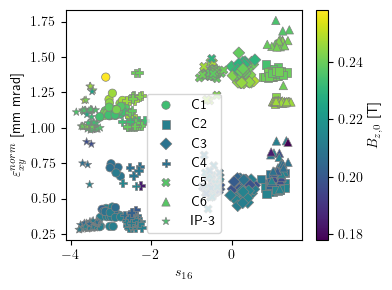

In [ ]:
show_and_save_opt_by_param_with_color_plot(
    pd.concat(
        [
            opt_per_shape_cluster_with_noise_table,
            opt_per_shape_cluster_with_noise_table2,
        ]
    ),
    y_optimize_for,
    "latent vector component 16",
    color_param="gun_B_max",
    # y_log=True,
    save=True,
)

In [270]:
def make_opt_by_params_3d_plot(
    opt_table: pd.DataFrame,
    y_optimize_for: str,
    show_x1_param: str,
    show_x2_param: str,
    save: bool = True,
    x1_log: bool = False,
    x2_log: bool = False,
    y_log: bool = False,
    file_name_suffix: str = "",
):
    fig = go.Figure()
    for cluster_id, df in opt_table.groupby("laser_pulse_shape_cluster_id"):
        fig.add_trace(
            go.Scatter3d(
                x=df[show_x1_param],
                y=df[show_x2_param],
                z=df[y_optimize_for],
                mode="markers",
                name=cluster_id,
                marker=dict(
                    size=7,
                    color=cluster_id_cmap[cluster_id],
                    line=dict(color="black", width=1),
                ),
            )
        )
    fig.update_layout(
        title=f"optimal {y_optimize_for} vs. ({show_x1_param}, {show_x2_param}) per laser pulse shape cluster",
        scene=dict(
            xaxis_title=show_x1_param,
            yaxis_title=show_x2_param,
            zaxis_title=y_optimize_for,
            xaxis=dict(type="log" if x1_log else "linear"),
            yaxis=dict(type="log" if x2_log else "linear"),
            zaxis=dict(type="log" if y_log else "linear"),
            aspectmode="cube",
        ),
    )

    if save:
        fig.write_image(
            f"{best_version_path}/eval/opt_{y_optimize_for}_vs_{show_x1_param}_{show_x2_param}_{file_name_suffix}.pdf"
        )

    return fig


make_opt_by_params_3d_plot(
    pd.concat(
        [
            opt_per_shape_cluster_with_noise_table,
            opt_per_shape_cluster_with_noise_table2,
        ]
    ),
    y_optimize_for,
    "PC1",
    "gun_B_max",
    y_log=True,
    save=False,
).show()

In [271]:
for cluster_id, df in pd.concat(
    [opt_per_shape_cluster_with_noise_table, opt_per_shape_cluster_with_noise_table2]
).groupby("laser_pulse_shape_cluster_id"):
    df = df.select_dtypes(include="number")
    corr = df.corr()
    corr = corr[x_params].loc[y_params]
    px.imshow(
        corr,
        title=f"correlation matrix for cluster {cluster_id} with noise_std={mean_lat_vecs_noise_std}",
        color_continuous_scale="RdBu",
        zmin=-1,
        zmax=1,
    ).show()
    px.scatter(
        df,
        x="norm_emit_x-final",
        y="gun_phase",
    ).show()

In [272]:
for x_param in (x for x in x_params if not x.startswith("latent")):
    fig = px.scatter(
        pd.concat(
            [
                opt_per_shape_cluster_with_noise_table,
                opt_per_shape_cluster_with_noise_table2,
            ]
        ),
        x="PC1",
        y=y_optimize_for,
        color=x_param,
        symbol="laser_pulse_shape_cluster_id",
        symbol_map=cluster_id_marker_map,
    )
    # make markers more visible
    fig.update_traces(marker=dict(line=dict(color="black", width=1)))
    # move legend
    fig.update_layout(legend=dict(x=0.01, y=-0.01, xanchor="left", yanchor="top"))
    fig.show()

In [273]:
px.imshow(
    pd.concat([opt_per_shape_cluster_table, opt_per_shape_cluster_with_noise_table2])
    .select_dtypes(include="number")
    .corr()[x_params]
    .loc[y_params],
    title=f"correlation matrix with noise_std={mean_lat_vecs_noise_std}",
    color_continuous_scale="RdBu",
    zmin=-1,
    zmax=1,
)

In [334]:
def show_3d_scan(
    x0: pd.Series,
    x1_param: str,
    x1_range: tuple[float, float, int],
    x2_param: str,
    x2_range: tuple[float, float, int],
    y_param: str,
    x_ranges_relative: bool = False,
    title_suffix: str = "",
    opts=opt_per_shape_cluster_table,
):
    table = pd.DataFrame()
    x1s = np.linspace(*x1_range)
    x2s = np.linspace(*x2_range)
    if x_ranges_relative:
        x1s = x0[x1_param] + x1s
        x2s = x0[x2_param] + x2s
    for x2 in x2s:
        for x1 in x1s:

            # x in physical space
            x = torch.tensor(x0.to_list(), dtype=model.dtype)
            x[x_params.index(x1_param)] = x1
            x[x_params.index(x2_param)] = x2

            # y = f(x) in physical space
            x = trafo_x(x.unsqueeze(0)).squeeze(0)

            y = model(x).detach()

            x = back_trafo_x(x.unsqueeze(0)).squeeze(0)
            y = back_trafo_y(y.unsqueeze(0)).squeeze(0)

            # append row
            x = pd.Series({p: x[i].item() for i, p in enumerate(x_params)})
            y = pd.Series({p: y[i].item() for i, p in enumerate(y_params)})

            row = pd.concat([x, y]).to_frame().T.copy()
            table = pd.concat([table, row], ignore_index=True)

    fig = go.Figure(
        go.Surface(
            x=x1s,
            y=x2s,
            z=table[y_param].values.reshape(len(x1s), len(x2s)),
            opacity=0.5,
            contours={
                "z": dict(
                    show=True,
                    start=table[y_param].min(),
                    end=table[y_param].max(),
                    size=np.ptp(table[y_param]) / 10,
                )
            },
        )
    )
    for cluster_id, df in opts.groupby("laser_pulse_shape_cluster_id"):
        fig.add_trace(
            go.Scatter3d(
                x=df[x1_param],
                y=df[x2_param],
                z=df[y_param],
                mode="markers",
                marker=dict(
                    color=cluster_id_cmap[cluster_id],
                    # symbol=cluster_id_marker_map[cluster_id],
                    # size=5,
                ),
                name=cluster_id,
            )
        )
    fig.update_layout(legend=dict(x=0.01, y=-0.01, xanchor="left", yanchor="top"))
    fig.update_layout(
        title=f"3D scan of {y_param} over {x1_param} and {x2_param} {title_suffix}",
        scene=dict(
            xaxis_title=x1_param,
            yaxis_title=x2_param,
            zaxis_title=y_param,
        ),
    )

    fig.write_image(
        f"{best_version_path}/eval/3d_scan_of_{y_param}_over_{x1_param}_and_{x2_param}.pdf"
    )

    fig.update_layout(width=800, height=600)
    fig.show()


show_3d_scan(
    x0=opt[x_params],
    x1_param="latent vector component 16",
    x1_range=(-4, 2, 25),
    x2_param="gun_phase",
    x2_range=(-6, 6, 25),
    y_param=y_optimize_for,
    title_suffix=f"surface=shape of overall optimal",
    opts=pd.concat(
        [
            opt_per_shape_cluster_with_noise_table,
            opt_per_shape_cluster_with_noise_table2,
        ]
    ),
)

In [335]:
show_3d_scan(
    x0=opt[x_params],
    x1_param="latent vector component 16",
    x1_range=(-4, 2, 25),
    x2_param="bunch_initial_t_rms",
    x2_range=(0.0001, 0.015, 25),
    y_param="std_z-final",
    opts=pd.concat(
        [
            opt_per_shape_cluster_with_noise_table,
            opt_per_shape_cluster_with_noise_table2,
        ]
    ),
)

In [336]:
show_3d_scan(
    x0=opt[x_params],
    x1_param="latent vector component 16",
    x1_range=(-4, 2, 25),
    x2_param="gun_B_max",
    x2_range=(0.15, 0.26, 25),
    y_param=y_optimize_for,
    title_suffix=f"surface=shape of overall optimal",
    opts=pd.concat(
        [
            opt_per_shape_cluster_with_noise_table,
            opt_per_shape_cluster_with_noise_table2,
        ]
    ),
)

In [337]:
show_3d_scan(
    x0=opt[x_params],
    x1_param="gun_phase",
    x1_range=(-6, 6, 25),
    x2_param="gun_B_max",
    x2_range=(0.15, 0.27, 25),
    y_param=y_optimize_for,
    title_suffix=f"surface=shape of overall optimal",
    opts=pd.concat(
        [
            opt_per_shape_cluster_with_noise_table,
            opt_per_shape_cluster_with_noise_table2,
        ]
    ),
)